In [ ]:
import marimo as mo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

In [ ]:
# Load data
train = pd.read_csv('data/polynomial_train-1.csv')
x_train, y_train = train['X'].to_numpy(), train['Y'].to_numpy()

test = pd.read_csv('data/polynomial_test-1.csv')
x_test, y_test = test['X'].to_numpy(), test['Y'].to_numpy()

In [ ]:
# Transform data
degree = 6
X_train = np.array([x_train] * degree).T
X_test = np.array([x_test] * degree).T

# Create polynomial variables
for i in range(degree):
    X_train[:,i] = X_train[:,i] ** i
    X_test[:, i] = X_test[:, i] ** i

# Q3: Posterior Inference

Write code to get the posterior distribution of the
weights, $p(w|D)$. Assume a gaussian prior for the weights, $p(w) = N (w|w_0)$ as
defined above. Run this code to estimate the posterior of each of the weights, $w_j$
(hint: this is a closed form set of equations discussed in class and in Murphy).
Plot a KDE or histogram for each weight, $w_j$ (hint: there should be six plots,
one for each of the five polynomial coefficient plus the intercept term).

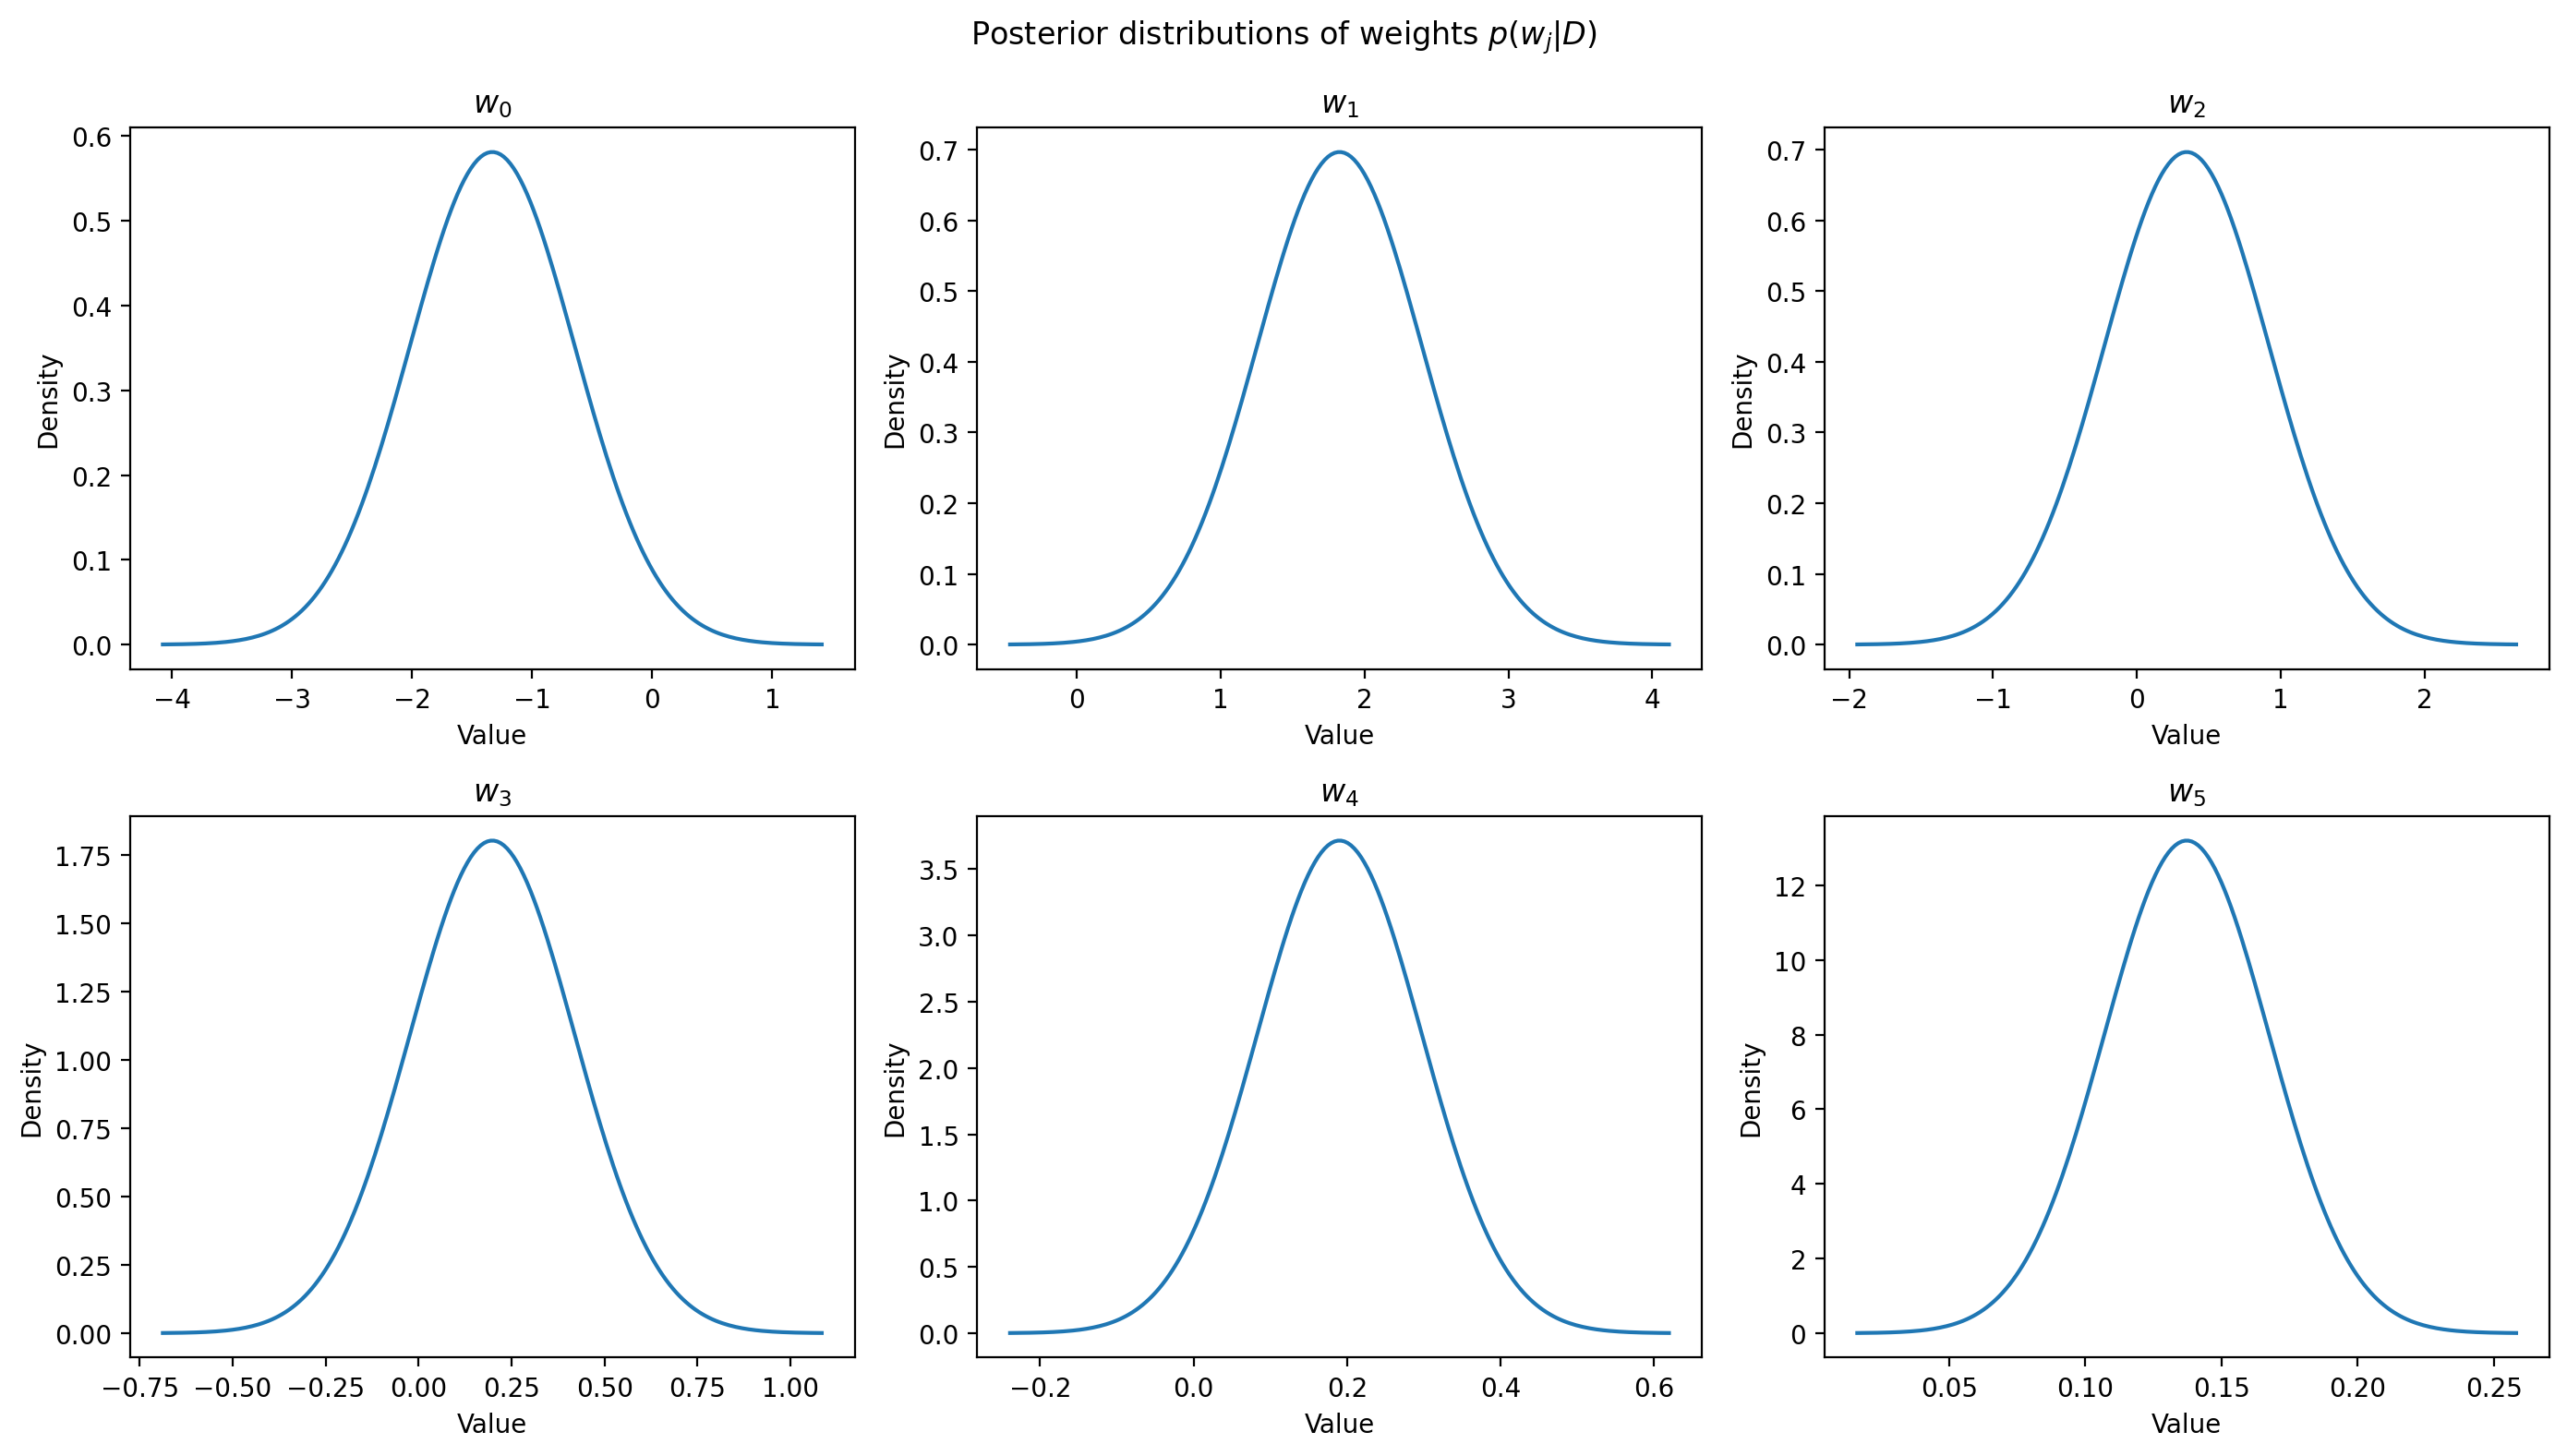

In [ ]:
# Priors
w_prior = np.zeros(degree)
tau = 1
Sigma_prior = tau**2 * np.eye(degree)
sigma = 1

Sigma_n = np.linalg.inv(np.linalg.inv(Sigma_prior) + (1 / sigma**2) * (X_train.T @ X_train))
mu_n = Sigma_n @ (np.linalg.inv(Sigma_prior) @ w_prior + (1 / sigma**2) * (X_train.T @ y_train))

# Plot marginal posterior for each weight
_, axes_post = plt.subplots(2, 3, figsize=(14, 8))
for j, _ax in enumerate(axes_post.flat):
    mean_j = mu_n[j]
    std_j = np.sqrt(Sigma_n[j, j])
    x = np.linspace(mean_j - 4 * std_j, mean_j + 4 * std_j, 200)
    _ax.plot(x, norm.pdf(x, loc=mean_j, scale=std_j))
    _ax.set_title(f"$w_{j}$")
    _ax.set_xlabel("Value")
    _ax.set_ylabel("Density")

plt.suptitle("Posterior distributions of weights $p(w_j | D)$")
plt.tight_layout()
plt.show()